<a href="https://colab.research.google.com/github/bhatiatanya81-code/Capstone-Assignment-Deep-Learning/blob/main/Experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name= Tanya Bhatia

### Roll No= 2501940069

---

### EXPERIMENT 2 (CNN)

---

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.7991 - loss: 0.5592 - val_accuracy: 0.8738 - val_loss: 0.3563
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.8688 - loss: 0.3608 - val_accuracy: 0.8791 - val_loss: 0.3239
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.8865 - loss: 0.3120 - val_accuracy: 0.8941 - val_loss: 0.2858
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.8978 - loss: 0.2804 - val_accuracy: 0.8982 - val_loss: 0.2823
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9063 - loss: 0.2576 - val_accuracy: 0.9028 - val_loss: 0.2649
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9124 - loss: 0.2392 - val_accuracy: 0.9112 - val_loss: 0.2451
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.9177 - loss: 0.2211 - val_accuracy: 0.9083 - val_loss: 0.2522
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.9238 - loss: 0.2056 - 

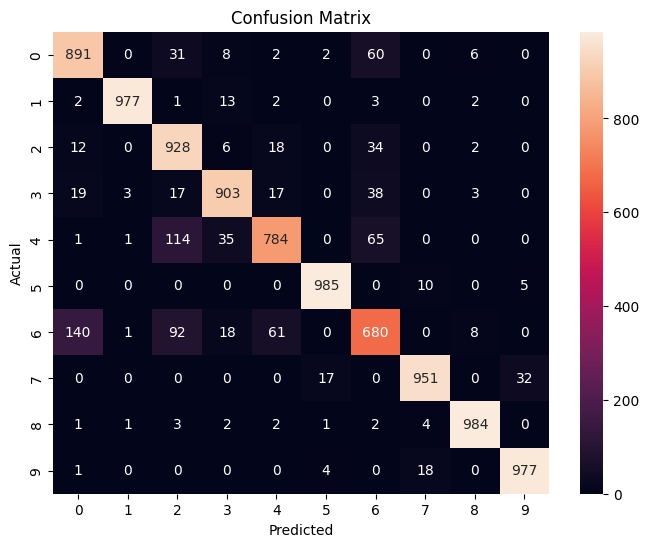

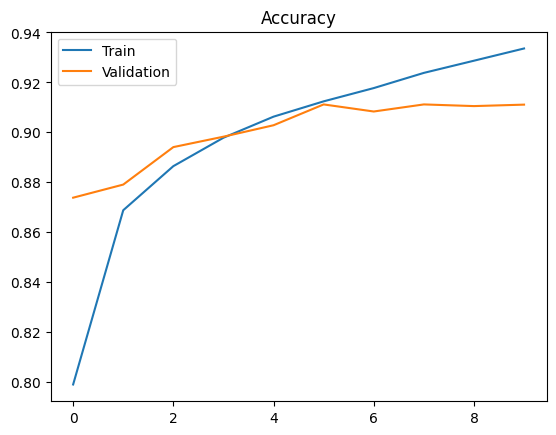

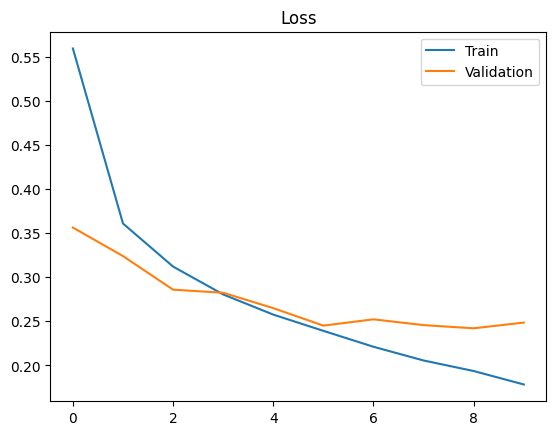

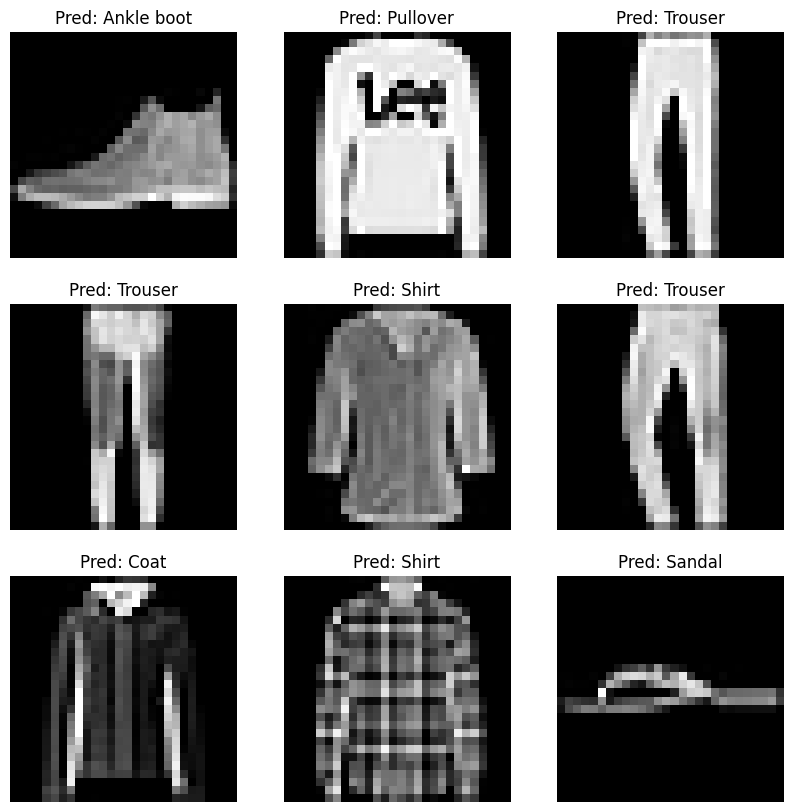

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# 2. LOAD DATASET
# ==============================
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# ==============================
# 3. PREPROCESSING
# ==============================

# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ==============================
# 4. BUILD CNN MODEL
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# ==============================
# 5. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 6. TRAIN MODEL
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ==============================
# 7. EVALUATE MODEL
# ==============================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# ==============================
# 8. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ==============================
# 9. CLASSIFICATION REPORT
# ==============================
print(classification_report(y_test, y_pred_classes))

# ==============================
# 10. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 11. PLOT TRAINING GRAPHS
# ==============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

# ==============================
# 12. SHOW SAMPLE PREDICTIONS
# ==============================
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()